In [ ]:
!pip uninstall datasets -y

In [ ]:
!pip install -q datasets==2.18.0 transformers accelerate scikit-learn seaborn

In [ ]:
import os, random
import numpy as np
import pandas as pd
import torch
import datasets
import seaborn as sns
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer, pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from google.colab import drive

In [5]:
print(datasets.__version__)

2.18.0


In [6]:
drive.mount("/content/drive")
parquet_path = "/content/drive/MyDrive/DataMining_Project/clothing_reviews.parquet"

df= pd.read_parquet(parquet_path)
df.head()

Mounted at /content/drive


,rating,bert_input,label
0,3.0,"Nice shirts, run very small I am 5’7” and weig...",1
1,5.0,Love it This is a great wardrobe staple. It is...,2
2,4.0,Good for fall It is a good fit for normal wear...,2
3,4.0,this shirt fit very nice and seems to be well ...,2
4,5.0,"Fits well, washes nice. This crop top sports b...",2


In [7]:
# save_folder = "/content/drive/MyDrive/DataMining_Project"
# os.makedirs(save_folder, exist_ok=True)
# parquet_path = f"{save_folder}/clothing_reviews.parquet"
# df.to_parquet(parquet_path, index=False)
# print("Saved successfully:")
# print(parquet_path)

In [8]:
# stream_dataset = load_dataset(
#     "McAuley-Lab/Amazon-Reviews-2023",
#     "raw_review_Clothing_Shoes_and_Jewelry",
#     split="full",
#     streaming=True,
#     trust_remote_code=True
# )

In [9]:
# sample = stream_dataset.shuffle(seed=42, buffer_size=10000).take(2500000)
# df = pd.DataFrame(sample)
# df.head()

In [10]:
# # Keep only columns needed before creating bert_input
# needed_columns = [
#     "rating",
#     "title",
#     "text"
# ]
# df = df[needed_columns]
# df.head()

In [11]:
# # Clean title and text
# df["title"] = df["title"].fillna("").astype(str).str.strip()
# df["text"] = df["text"].fillna("").astype(str).str.strip()

# # Remove rows where text became empty after cleaning
# df = df[df["text"].str.len() > 0].copy()

# # Create BERT input
# df["bert_input"] = np.where(
#     df["title"].str.len() > 0,
#     df["title"] + ". " + df["text"],
#     df["text"]
# )

# # Create sentiment label from rating
# rating = df["rating"].to_numpy()

# df["label"] = (
#     (rating >= 3).astype(np.int8) +
#     (rating >= 4).astype(np.int8)
# )
# df["label"] = df["label"].astype("int8")

# # Keep final BERT classification columns
# df = df[["rating", "bert_input", "label"]]

# df.head()

In [12]:
df.head()

,rating,bert_input,label
0,3.0,"Nice shirts, run very small I am 5’7” and weig...",1
1,5.0,Love it This is a great wardrobe staple. It is...,2
2,4.0,Good for fall It is a good fit for normal wear...,2
3,4.0,this shirt fit very nice and seems to be well ...,2
4,5.0,"Fits well, washes nice. This crop top sports b...",2


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

In [15]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("GPU available:", torch.cuda.is_available())

GPU available: True


In [16]:
label_names = {
    0: "negative",
    1: "neutral",
    2: "positive"
}
print(df["label"].map(label_names).value_counts(),  "\n")
print(df["label"].map(label_names).value_counts(normalize=True) * 100)

label
positive    1990262
negative     282297
neutral      227441
Name: count, dtype: int64 

label
positive    79.61048
negative    11.29188
neutral      9.09764
Name: proportion, dtype: float64


In [17]:
USE_BALANCED_SUBSET = True
MAX_PER_CLASS = 50000

if USE_BALANCED_SUBSET:
    balanced_parts = []

    for label in sorted(df["label"].unique()):
        class_df = df[df["label"] == label]
        n = min(MAX_PER_CLASS, len(class_df))

        sampled_class = class_df.sample(n=n, random_state=SEED)
        balanced_parts.append(sampled_class)

    work_df = pd.concat(balanced_parts, ignore_index=True)
    work_df = work_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    work_df = df.reset_index(drop=True)

print(work_df["label"].map(label_names).value_counts())
print("Total rows used:", len(work_df))

label
neutral     50000
negative    50000
positive    50000
Name: count, dtype: int64
Total rows used: 150000


In [18]:
work_df.head()

,rating,bert_input,label
0,3.0,Really not as pictured. Really not as pictured...,1
1,2.0,Way way big. Had to return. Thank you Amazon f...,0
2,5.0,"Stupendous! At the 6 number, it reads SWISS MA...",2
3,5.0,Highly Recommend Comfortable and great price.,2
4,5.0,"Great value, order 1 size larger Order xxl so ...",2


In [19]:
train_df, temp_df = train_test_split(
    work_df,
    test_size=0.20,
    random_state=SEED,
    stratify=work_df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (120000, 3)
Validation: (15000, 3)
Test: (15000, 3)


In [20]:
print("Train distribution:")
print(train_df["label"].map(label_names).value_counts())

print("\nValidation distribution:")
print(val_df["label"].map(label_names).value_counts())

print("\nTest distribution:")
print(test_df["label"].map(label_names).value_counts())

Train distribution:
label
positive    40000
negative    40000
neutral     40000
Name: count, dtype: int64

Validation distribution:
label
negative    5000
positive    5000
neutral     5000
Name: count, dtype: int64

Test distribution:
label
positive    5000
neutral     5000
negative    5000
Name: count, dtype: int64


In [22]:
def pandas_to_hf_dataset(dataframe):
    temp = dataframe[["bert_input", "label"]].copy()
    temp = temp.rename(columns={"bert_input": "text"})
    temp = temp.reset_index(drop=True)
    return Dataset.from_pandas(temp)

raw_datasets = DatasetDict({
    "train": pandas_to_hf_dataset(train_df),
    "validation": pandas_to_hf_dataset(val_df),
    "test": pandas_to_hf_dataset(test_df)
})

raw_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 15000
    })
})

In [23]:
#model_name = "bert-base-uncased"   #TRY
model_name = "distilbert-base-uncased"

In [24]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
MAX_LENGTH = 128
# MAX_LENGTH = 256  #TRY
# Most product reviews are not very long. 128 tokens is a good starting point. If you use 256, BERT sees more text but training becomes slower.

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = raw_datasets.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_datasets

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

Map:   0%|          | 0/15000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 15000
    })
})

In [26]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [27]:
id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [29]:
evaluation_strategy="epoch"

In [30]:
output_dir = "/content/drive/MyDrive/DataMining_Project/bert_sentiment_output"

training_args = TrainingArguments(
    output_dir=output_dir,

    eval_strategy="epoch",
    # evaluation_strategy="epoch"
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    save_total_limit=2,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

In [31]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],

    processing_class=tokenizer,
    # tokenizer=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.470603,0.483607,0.789733,0.790953,0.789733,0.788726
2,0.425510,0.481724,0.798133,0.798788,0.798133,0.798358


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=15000, training_loss=0.47337564951578776, metrics={'train_runtime': 1050.8368, 'train_samples_per_second': 228.389, 'train_steps_per_second': 14.274, 'total_flos': 7585723557198144.0, 'train_loss': 0.47337564951578776, 'epoch': 2.0})

In [33]:
test_results = trainer.evaluate(tokenized_datasets["test"])
test_results

{'eval_loss': 0.4937816262245178,
 'eval_accuracy': 0.7916666666666666,
 'eval_precision_macro': 0.7923839145151083,
 'eval_recall_macro': 0.7916666666666666,
 'eval_f1_macro': 0.7919390271482848,
 'eval_runtime': 14.6612,
 'eval_samples_per_second': 1023.106,
 'eval_steps_per_second': 31.989,
 'epoch': 2.0}

In [34]:
pred_output = trainer.predict(tokenized_datasets["test"])

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

print(classification_report(
    y_true,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

              precision    recall  f1-score   support

    negative       0.77      0.79      0.78      5000
     neutral       0.70      0.69      0.70      5000
    positive       0.91      0.89      0.90      5000

    accuracy                           0.79     15000
   macro avg       0.79      0.79      0.79     15000
weighted avg       0.79      0.79      0.79     15000



<Axes: >

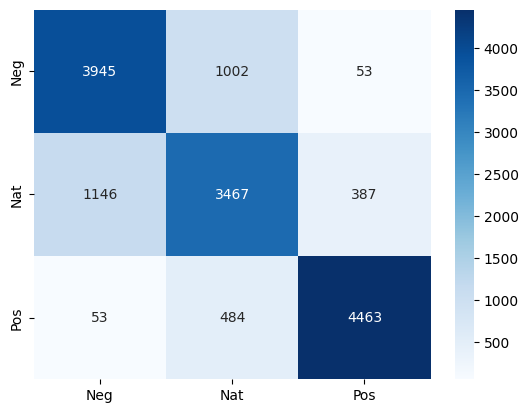

In [48]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm,xticklabels=['Neg','Nat','Pos'] ,yticklabels=['Neg','Nat','Pos'] ,annot=True, fmt="d", cmap="Blues")

In [36]:
model_save_path = "/content/drive/MyDrive/DataMining_Project/bert_sentiment_model"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print("Model saved to:", model_save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/DataMining_Project/bert_sentiment_model


Next Training

In [40]:
model_save_path = "/content/drive/MyDrive/DataMining_Project/bert_sentiment_model"

tokenizer = AutoTokenizer.from_pretrained(model_save_path)
model = AutoModelForSequenceClassification.from_pretrained(model_save_path)

device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [41]:
texts = [
    "The jacket fits perfectly and the quality is excellent.",
    "The shoes are uncomfortable and broke after two days.",
    "The shirt is okay, nothing special."
]

predictions = sentiment_pipeline(texts)

for text, pred in zip(texts, predictions):
    print(text)
    print(pred)
    print()

The jacket fits perfectly and the quality is excellent.
{'label': 'positive', 'score': 0.9931949377059937}

The shoes are uncomfortable and broke after two days.
{'label': 'negative', 'score': 0.9271770119667053}

The shirt is okay, nothing special.
{'label': 'neutral', 'score': 0.9375556111335754}

